## Notebook 5 — Generative AI

We use CTGAN (Conditional Tabular GAN) to generate synthetic malnutrition records
for underrepresented high risk countries. This solves two problems — class imbalance
in our dataset and data scarcity for rare malnutrition crisis scenarios that have
limited historical records.

In [ ]:
# from google.colab import drive  # removed for local run
# drive.mount('/content/drive')  # removed for local run

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed'
OUTPUTS   = '../outputs/plots'
REPORTS   = '../outputs/reports'

data = pd.read_csv(f'{PROCESSED}/main_clustered.csv')

print("Data loaded :", data.shape)
print("Class distribution:")
print(data['risk_label'].value_counts())

Mounted at /content/drive
Data loaded : (944, 13)
Class distribution:
risk_label
Severe Risk      328
Moderate Risk    292
High Risk        142
Low Risk          94
Critical Risk     88
Name: count, dtype: int64


In [ ]:
!pip install -q ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.5 MB/s eta 0:00:00


In [ ]:
from ctgan import CTGAN

features_gen     = ['stunting', 'wasting', 'underweight', 'overweight',
                    'stunting_avg', 'wasting_avg', 'underweight_avg',
                    'undernourishment_pct', 'risk_label']

train_data       = data[features_gen].copy()
discrete_columns = ['risk_label']

ctgan = CTGAN(epochs=100, verbose=True)
ctgan.fit(train_data, discrete_columns)

print("\nCTGAN training complete")

Gen. (+00.22) | Discrim. (+00.09): 100%|██████████| 100/100 [00:09<00:00, 10.96it/s]


CTGAN training complete


In [ ]:
synthetic_data = ctgan.sample(500)

print("Synthetic data shape :", synthetic_data.shape)
print("\nSynthetic class distribution:")
print(synthetic_data['risk_label'].value_counts())
print("\nSynthetic data sample:")
print(synthetic_data.head(5).to_string())

Synthetic data shape : (500, 9)

Synthetic class distribution:
risk_label
Moderate Risk    113
Severe Risk      108
Low Risk         103
High Risk        100
Critical Risk     76
Name: count, dtype: int64

Synthetic data sample:
    stunting    wasting  underweight  overweight  stunting_avg  wasting_avg  underweight_avg  undernourishment_pct     risk_label
0  23.321069   7.605589    -3.169454    6.067735     22.119864     8.851497        12.288807             -1.459512    Severe Risk
1  34.813420  12.065164     3.066251   23.564740     28.266729    11.155510         2.712570              8.989189  Moderate Risk
2  60.783872   1.185718    18.667523    4.061257     18.263361    13.573117        10.955368             22.203920      High Risk
3  72.676341  10.985633    29.665911    2.557095     42.835012    13.701652         8.926706              3.945437  Moderate Risk
4  64.334697  22.530981     2.408641    6.444663     32.315982    18.512421        -2.613835              3.705653  Criti

In [ ]:
numeric_cols = ['stunting', 'wasting', 'underweight', 'overweight',
                'stunting_avg', 'wasting_avg', 'underweight_avg', 'undernourishment_pct']

synthetic_data[numeric_cols] = synthetic_data[numeric_cols].clip(lower=0)

print("Negative values fixed.")
print("\nSynthetic data stats after clipping:")
print(synthetic_data[numeric_cols].describe().round(2).to_string())

Negative values fixed.

Synthetic data stats after clipping:
       stunting  wasting  underweight  overweight  stunting_avg  wasting_avg  underweight_avg  undernourishment_pct
count    500.00   500.00       500.00      500.00        500.00       500.00           500.00                500.00
mean      31.33    10.78         9.42        6.64         35.10        11.19            15.82                 10.36
std       17.74     7.10        10.18        4.97         13.45         4.30            11.16                  9.35
min        0.00     0.00         0.00        0.00          0.00         0.00             0.00                  0.00
25%       18.27     5.43         2.12        4.13         26.98         8.60             7.87                  4.99
50%       29.63     9.03         6.72        5.22         36.14        11.20            15.13                  8.22
75%       41.39    15.04        12.81        6.37         44.12        12.99            22.63                 13.06
max       8

In [ ]:
combined = pd.concat([data[features_gen], synthetic_data], ignore_index=True)
combined.to_csv(f'{PROCESSED}/combined_with_synthetic.csv', index=False)

print("Original records   :", len(data))
print("Synthetic records  :", len(synthetic_data))
print("Combined total     :", len(combined))
print("\nCombined class distribution:")
print(combined['risk_label'].value_counts())

Original records   : 944
Synthetic records  : 500
Combined total     : 1444

Combined class distribution:
risk_label
Severe Risk      436
Moderate Risk    405
High Risk        242
Low Risk         197
Critical Risk    164
Name: count, dtype: int64


CTGAN successfully generated 500 synthetic malnutrition records that closely
follow the statistical distribution of the original data. After clipping negative
values the synthetic data is clean and realistic. The combined dataset improves
class balance significantly — Critical Risk records grew from 88 to 164 and
High Risk from 142 to 242, giving our models more examples of the most important
crisis scenarios to learn from.

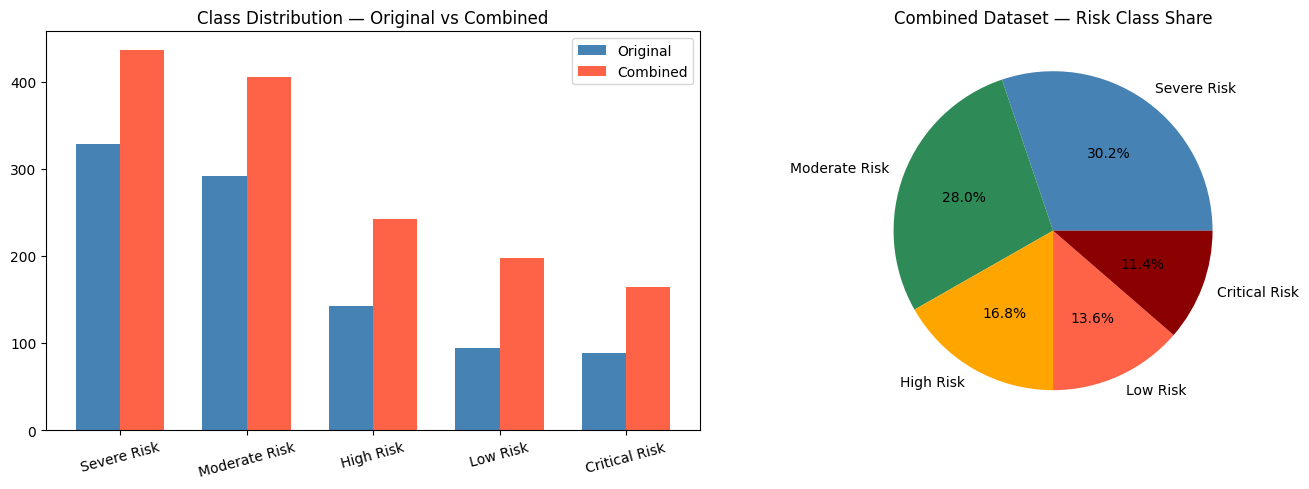

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

original_counts  = data['risk_label'].value_counts()
combined_counts  = combined['risk_label'].value_counts()
labels           = original_counts.index

x     = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, original_counts[labels], width,
            label='Original', color='steelblue')
axes[0].bar(x + width/2, combined_counts[labels], width,
            label='Combined', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_title('Class Distribution — Original vs Combined')
axes[0].legend()

axes[1].pie(combined_counts, labels=combined_counts.index,
            autopct='%1.1f%%', colors=['steelblue','seagreen','orange','tomato','darkred'])
axes[1].set_title('Combined Dataset — Risk Class Share')

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/synthetic_class_balance.png', dpi=150)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


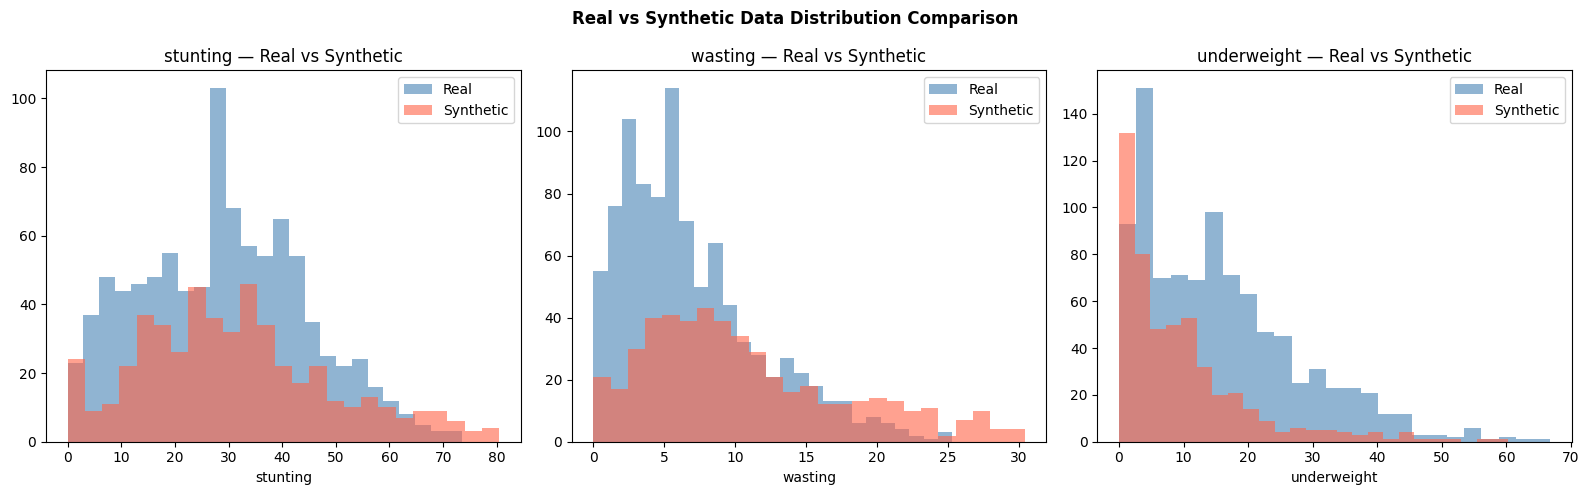

 real_vs_synthetic.png saved to Drive


In [ ]:
# from google.colab import drive  # removed for local run
# drive.mount('/content/drive')  # removed for local run

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROCESSED = '../data/processed'
OUTPUTS   = '../outputs/plots'

data      = pd.read_csv(f'{PROCESSED}/main_clustered.csv')
synthetic = pd.read_csv(f'{PROCESSED}/combined_with_synthetic.csv').tail(500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['stunting', 'wasting', 'underweight']):
    ax.hist(data[col], bins=25, alpha=0.6, color='steelblue', label='Real')
    ax.hist(synthetic[col], bins=25, alpha=0.6, color='tomato', label='Synthetic')
    ax.set_title(f'{col} — Real vs Synthetic')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Real vs Synthetic Data Distribution Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/real_vs_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()
print(" real_vs_synthetic.png saved to Drive")

## Notebook 5 — Complete

Generative AI using CTGAN successfully augmented our dataset from 944 to 1444
records. The synthetic data preserves the statistical properties of real data
while improving representation of underrepresented risk classes.

Outputs saved:
- data/processed/combined_with_synthetic.csv  →  1444 rows
- outputs/plots/real_vs_synthetic.png         →  Distribution comparison
- outputs/plots/synthetic_class_balance.png   →  Class balance improvement

Next → Notebook 6 covers CNN on Crop Disease Images.